## Deep Learning Foundations with Keras Tutorial

In [1]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import tensorflow as tf

### Helper functions

In [2]:
def plot_convergence_history(history):
    train_loss = history.history['loss']
    val_loss = history.history['val_loss']
    train_accuracy = history.history['accuracy']
    val_accuracy = history.history['val_accuracy']

    # Create subplots
    fig, axs = plt.subplots(1, 2, figsize=(14, 5))

    # Plot training and validation loss
    axs[0].plot(train_loss, label='Training Loss')
    axs[0].plot(val_loss, label='Validation Loss')
    axs[0].set_title('Training and Validation Loss')
    axs[0].set_xlabel('Epochs')
    axs[0].set_ylabel('Loss')
    axs[0].legend()

    # Plot training and validation accuracy
    axs[1].plot(train_accuracy, label='Training Accuracy')
    axs[1].plot(val_accuracy, label='Validation Accuracy')
    axs[1].set_title('Training and Validation Accuracy')
    axs[1].set_xlabel('Epochs')
    axs[1].set_ylabel('Accuracy')
    axs[1].legend()

    # Show the plot
    plt.tight_layout()
    plt.show()

# Introduction to MNIST dataset and data preprocessing  
We begin by loading the handwritten digits dataset and normalizing pixel values to [0,1]. Images are flattened from 28x28 to 784-dimensional vectors for dense network input.


In [3]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train = x_train.reshape(60000, 784).astype('float32') / 255
x_test = x_test.reshape(10000, 784).astype('float32') / 255
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
x_train.shape

(60000, 784)

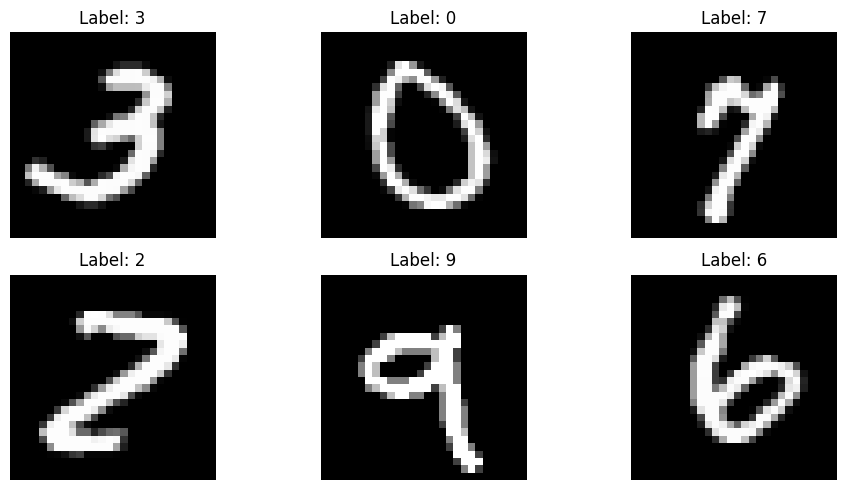

In [5]:
# Visualize 6 random images from the data
random_indices = np.random.choice(x_train.shape[0], 6, replace=False)
random_images = x_train[random_indices]

# Reshape images back to 28x28 pixels
random_images = random_images.reshape(6, 28, 28)

# Plot the images
plt.figure(figsize=(10, 5))
for i in range(6):
    plt.subplot(2, 3, i+1)
    plt.imshow(random_images[i], cmap='gray')
    plt.axis('off')
    plt.title(f"Label: {np.argmax(y_train[random_indices[i]])}")

plt.tight_layout()
plt.show()

# Activation Functions and Network Architecture  
This basic model demonstrates:  
 - Sigmoid activation in hidden layers (historically common but suboptimal -- should not use before the last layer in most cases)  
 - Softmax output for probability distribution  
 - Cross-entropy loss for classification

In [6]:
base_model = Sequential([
    Dense(512, activation='sigmoid', input_shape=(784,)), # suboptimal to use sigmoid before the last hidden layer
    Dense(10, activation='softmax')
])

base_model.compile(optimizer='rmsprop',
                 loss='categorical_crossentropy',
                 metrics=['accuracy'])

c:\Users\NoahMSOE\code\CSC6621\project-2-neural-networks\.venv\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### Network architecture and total number of parameters

In [7]:
base_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 407,050 (1.55 MB)

 Trainable params: 407,050 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

Notes:
- Non-trainable params refer to parameters that are not updated during training. These could be parameters related to certain layers, like in frozen layers (e.g., in transfer learning, where certain layers are frozen) or certain layers like batch normalization layers, which we will cover later.
- The `None` in Output Shape refers to the batch size, which is flexible during training or inference. The actual batch size is determined by the input data and is not specified in the model summary.

### Start training

In [8]:
history = base_model.fit(x_train, y_train,
                        epochs=20,
                        batch_size=128,
                        validation_split=0.2)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7940 - loss: 0.7952 - val_accuracy: 0.9123 - val_loss: 0.2979
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9135 - loss: 0.2970 - val_accuracy: 0.9299 - val_loss: 0.2495
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9285 - loss: 0.2457 - val_accuracy: 0.9382 - val_loss: 0.2148
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9376 - loss: 0.2119 - val_accuracy: 0.9475 - val_loss: 0.1887
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9500 - loss: 0.1685 - val_accuracy: 0.9548 - val_loss: 0.1623
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9567 - loss: 0.1495 - val_accuracy: 0.9559 - val_loss: 0.1549
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9628 - loss: 0.1289 - val_accuracy: 0.9620 - val_loss: 0.1348
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9669 - loss: 0.1142 - val_accuracy: 0.

### Visualize convergence history

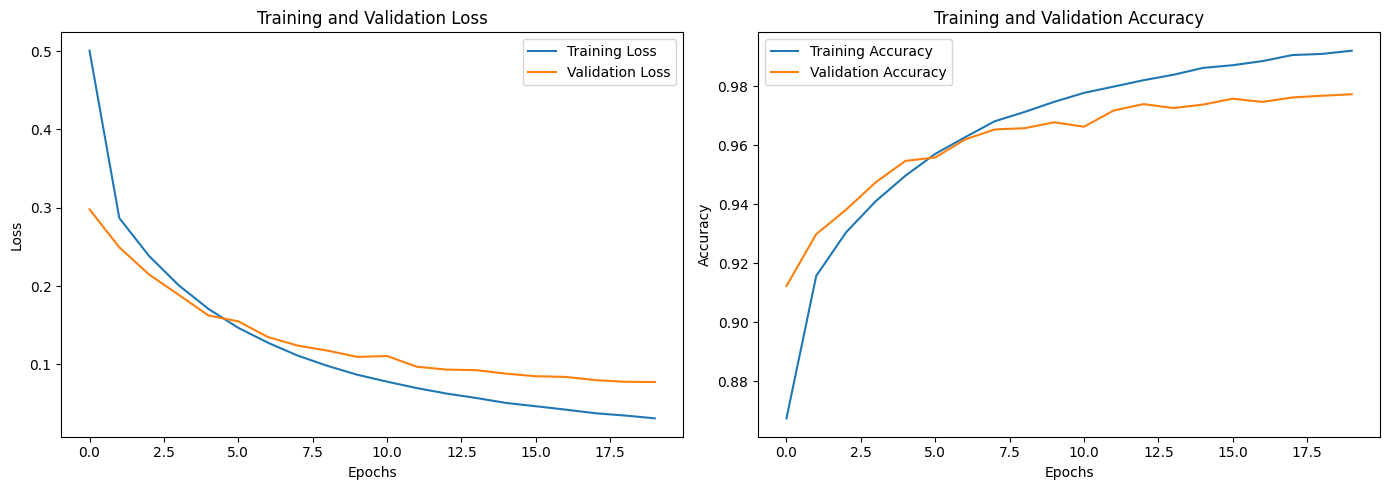

In [9]:
plot_convergence_history(history)

### Model performance on the test set

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 948us/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9742 - loss: 0.0795
Test Loss: 0.0679
Test Accuracy: 0.9781
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.98      0.98      1032
           3       0.97      0.98      0.98      1010
           4       0.98      0.97      0.98       982
           5       0.98      0.97      0.97       892
           6       0.97      0.98      0.98       958
           7       0.98      0.97      0.98      1028
           8       0.97      0.97      0.97       974
           9       0.98      0.97      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



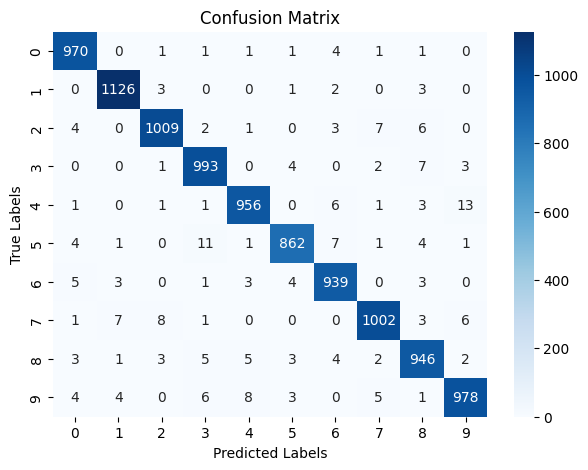

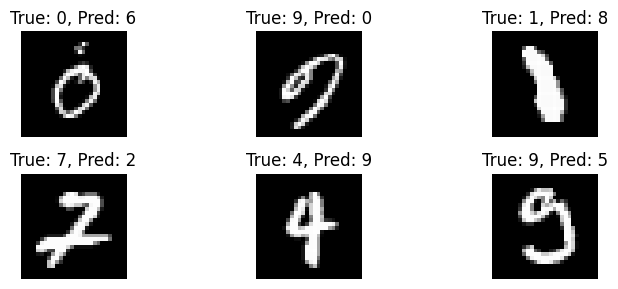

In [10]:
y_pred = base_model.predict(x_test)

# Convert predictions from one-hot encoding to class labels
y_pred_classes = np.argmax(y_pred, axis=1)
y_test_classes = np.argmax(y_test, axis=1)

# Evaluate the model on the test set
test_loss, test_accuracy = base_model.evaluate(x_test, y_test)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Print a classification report (precision, recall, F1-score per class)
print(classification_report(y_test_classes, y_pred_classes))

cm = confusion_matrix(y_test_classes, y_pred_classes)

# Visualize the confusion matrix using seaborn heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.arange(10), yticklabels=np.arange(10))
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

# Visualizing incorrectly predicted samples
incorrect_indices = np.where(y_pred_classes != y_test_classes)[0]

# Choose 6 random incorrect predictions to visualize
incorrect_sample_indices = np.random.choice(incorrect_indices, 6, replace=False)

# Plot the incorrectly predicted samples
plt.figure(figsize=(8, 3))
for i, idx in enumerate(incorrect_sample_indices):
    plt.subplot(2, 3, i+1)
    plt.imshow(x_test[idx].reshape(28, 28), cmap='gray')
    plt.title(f"True: {y_test_classes[idx]}, Pred: {y_pred_classes[idx]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

### Report per class accuracies

In [11]:
per_class_accuracy = np.diagonal(cm) / np.sum(cm, axis=1)

print("Per-class Accuracy:")
for i, accuracy in enumerate(per_class_accuracy):
    print(f"Class {i}: {accuracy:.4f}")


Per-class Accuracy:
Class 0: 0.9898
Class 1: 0.9921
Class 2: 0.9777
Class 3: 0.9832
Class 4: 0.9735
Class 5: 0.9664
Class 6: 0.9802
Class 7: 0.9747
Class 8: 0.9713
Class 9: 0.9693


Notes:
- Macro averaging calculates metrics for each class independently and averages them. 
    - It treats all classes equally, regardless of their support (number of instances). 
    - If you want to treat all classes equally, then using macro average would be a good choice.
- Weighted averaging takes into account the support of each class, meaning the classes with more instances have a larger influence on the overall metrics. 
    - If you have an imbalanced dataset but want to assign more weight to classes with more samples, consider using weighted average.
- Micro averaging (not reported above), on the other hand, calculates overall metrics by aggregating true positives, false positives, and false negatives across all classes before computing precision, recall, and F1-score. 
    - In the case of multi-class classification, micro-averaged precision, recall, and accuracy are the same.

### Overfitting Detection and Regularization  

If comparing validation/training loss reveals overfitting then we can combat this with:  
 - L2 regularization (weight decay), more on this in the lectures
 - Dropout (random neuron deactivation), which we'll be covered in more detail in lectures.
 - Reduced network capacity

In [12]:
regularized_model = Sequential([
    Dense(512, activation='relu', kernel_regularizer=l2(0.001),
          input_shape=(784,)),
    Dropout(0.5),
    Dense(512, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

regularized_model.compile(optimizer='rmsprop',
                        loss='categorical_crossentropy',
                        metrics=['accuracy'])

history_reg = regularized_model.fit(x_train, y_train,
                                   epochs=40,
                                   batch_size=128,
                                   validation_split=0.2)

Epoch 1/40


c:\Users\NoahMSOE\code\CSC6621\project-2-neural-networks\.venv\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8002 - loss: 1.4358 - val_accuracy: 0.9523 - val_loss: 0.4915
Epoch 2/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9363 - loss: 0.4929 - val_accuracy: 0.9643 - val_loss: 0.3129
Epoch 3/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9438 - loss: 0.3622 - val_accuracy: 0.9646 - val_loss: 0.2724
Epoch 4/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9503 - loss: 0.3117 - val_accuracy: 0.9676 - val_loss: 0.2503
Epoch 5/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9528 - loss: 0.2921 - val_accuracy: 0.9699 - val_loss: 0.2300
Epoch 6/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9538 - loss: 0.2770 - val_accuracy: 0.9682 - val_loss: 0.2322
Epoch 7/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9538 - loss: 0.2733 - val_accuracy: 0.9661 - val_loss: 0.2319
Epoch 8/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9539 - loss: 0.2722 - val_accuracy: 0.9677 - val_

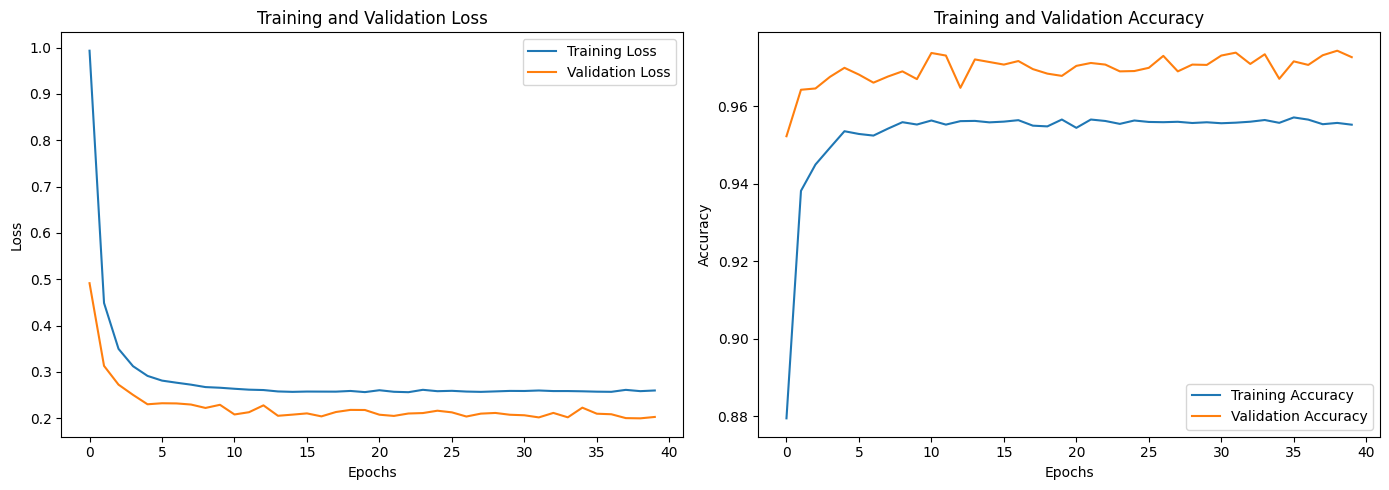

In [13]:
plot_convergence_history(history_reg)

### Non-Linear Activation Comparison  
- ReLU is typically preferred in hidden layers of deep networks because of its ability to avoid vanishing gradients and faster learning. However, some care needs to be taken with its potential for "dead neurons" (e.g., using techniques like Leaky ReLU or Parametric ReLU to mitigate this).
- Sigmoid is often used in the output layer for binary classification tasks where the output needs to be interpreted as a probability, since it maps outputs to a range between 0 and 1.
- Potential diagnosis of gradient vanishing problem:
    - Monitor the training loss during the training process. If it stays constant or decreases very slowly (even with a reasonable learning rate), it's possible that the gradients are vanishing, especially in deeper layers.
    - You can print or log the gradients during backpropagation for the weights or activations. If you observe that the gradients are extremely small in deeper layers (e.g., close to 0), then it's a sign that the gradients are vanishing.

In [14]:
relu_model = Sequential([
    Dense(512, activation='relu', input_shape=(784,)),
    Dense(10, activation='softmax')
])

relu_model.compile(optimizer='rmsprop',
                 loss='categorical_crossentropy',
                 metrics=['accuracy'])

history_relu = relu_model.fit(x_train, y_train,
                            epochs=20,
                            batch_size=128,
                            validation_split=0.2)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8567 - loss: 0.4818 - val_accuracy: 0.9581 - val_loss: 0.1455
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9619 - loss: 0.1322 - val_accuracy: 0.9694 - val_loss: 0.1064
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9762 - loss: 0.0818 - val_accuracy: 0.9743 - val_loss: 0.0859
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9844 - loss: 0.0547 - val_accuracy: 0.9763 - val_loss: 0.0788
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9876 - loss: 0.0419 - val_accuracy: 0.9793 - val_loss: 0.0736
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9919 - loss: 0.0303 - val_accuracy: 0.9787 - val_loss: 0.0752
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9940 - loss: 0.0237 - val_accuracy: 0.9773 - val_loss: 0.0765
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9955 - loss: 0.0178 - val_accuracy: 0.

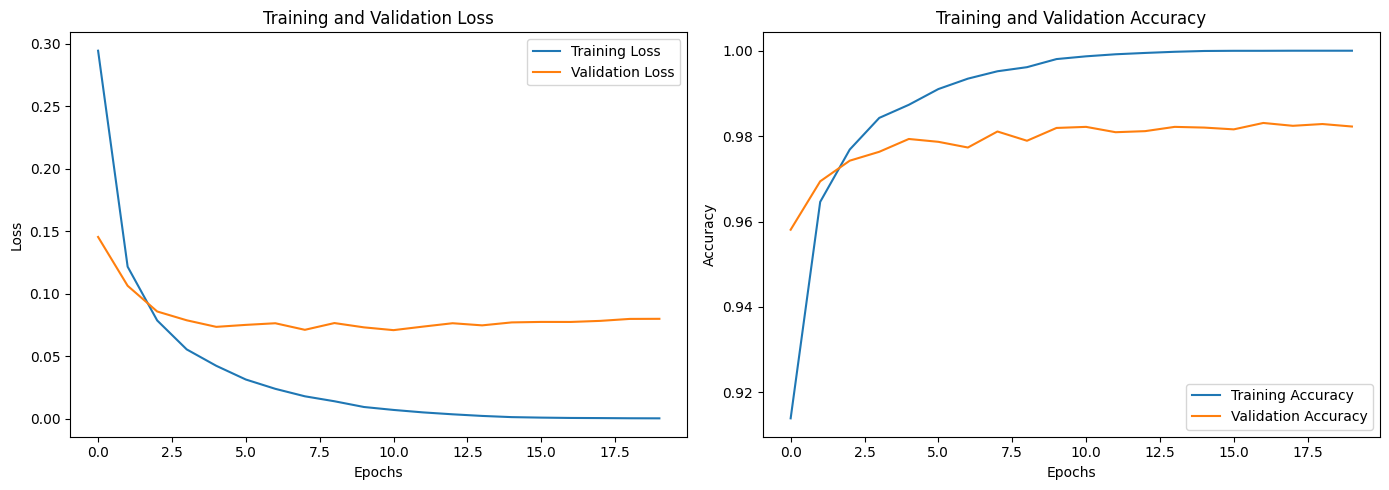

In [15]:
plot_convergence_history(history_relu)

### Printing gradients to diagnose potential gradient vanishing problems 

In [16]:
loss_fn = tf.keras.losses.CategoricalCrossentropy(from_logits=False)

with tf.GradientTape() as tape:
    predictions = relu_model(x_train)
    loss = loss_fn(predictions, y_train)

grads = tape.gradient(loss, relu_model.trainable_variables)
print(grads)  # Check the gradients for each layer


[<tf.Tensor: shape=(784, 512), dtype=float32, numpy=
array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)>, <tf.Tensor: shape=(512,), dtype=float32, numpy=
array([ 7.11232133e-05,  7.26050712e-05,  3.54130403e-04, -3.64540145e-04,
       -5.26280564e-05,  1.69050065e-04,  4.92443214e-04, -1.11742840e-04,
        1.03587918e-04, -7.03873578e-04,  5.79099142e-05, -1.22717611e-05,
       -2.02065858e-04,  2.99529580e-04, -4.83581040e-04, -4.59598843e-04,
        2.34090840e-04, -1.29930093e-04, -2.35510495e-04, -2.83751597e-05,
        3.00179585e-04,  5.39250068e-05,  1.28104642e-04, -1.85805809e-04,
       -1.53281271e-05, -1.46355014e-05, -5.94993529e-04, -1.73680019e-05,
       -4.61676282e-05, -1.33325957e-05, -4.53110260e-04, -1.96582521e-04,
        4.62551892e-04,  2.16842353e-04, 

In [17]:
grads[3].shape

TensorShape([10])

### Model Capacity and Underfitting  

A shallow network demonstrates:  
- High bias (underfitting)  
- Limited representational power  
- Both training and validation poor performance

In [18]:
underfit_model = Sequential([
    Dense(16, activation='relu', input_shape=(784,)),
    Dense(10, activation='softmax')
])

underfit_model.compile(optimizer='rmsprop',
                      loss='categorical_crossentropy',
                      metrics=['accuracy'])

history_underfit = underfit_model.fit(x_train, y_train,
                                     epochs=20,
                                     batch_size=128,
                                     validation_split=0.2)


Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6889 - loss: 1.0950 - val_accuracy: 0.9047 - val_loss: 0.3399
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9056 - loss: 0.3376 - val_accuracy: 0.9196 - val_loss: 0.2786
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9217 - loss: 0.2781 - val_accuracy: 0.9268 - val_loss: 0.2581
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9290 - loss: 0.2532 - val_accuracy: 0.9337 - val_loss: 0.2389
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9344 - loss: 0.2308 - val_accuracy: 0.9355 - val_loss: 0.2294
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9375 - loss: 0.2198 - val_accuracy: 0.9405 - val_loss: 0.2172
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9417 - loss: 0.2059 - val_accuracy: 0.9405 - val_loss: 0.2123
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9432 - loss: 0.1996 - val_accuracy: 0.

In [19]:
underfit_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 16)             │        12,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,462 (99.46 KB)

 Trainable params: 12,730 (49.73 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 12,732 (49.74 KB)

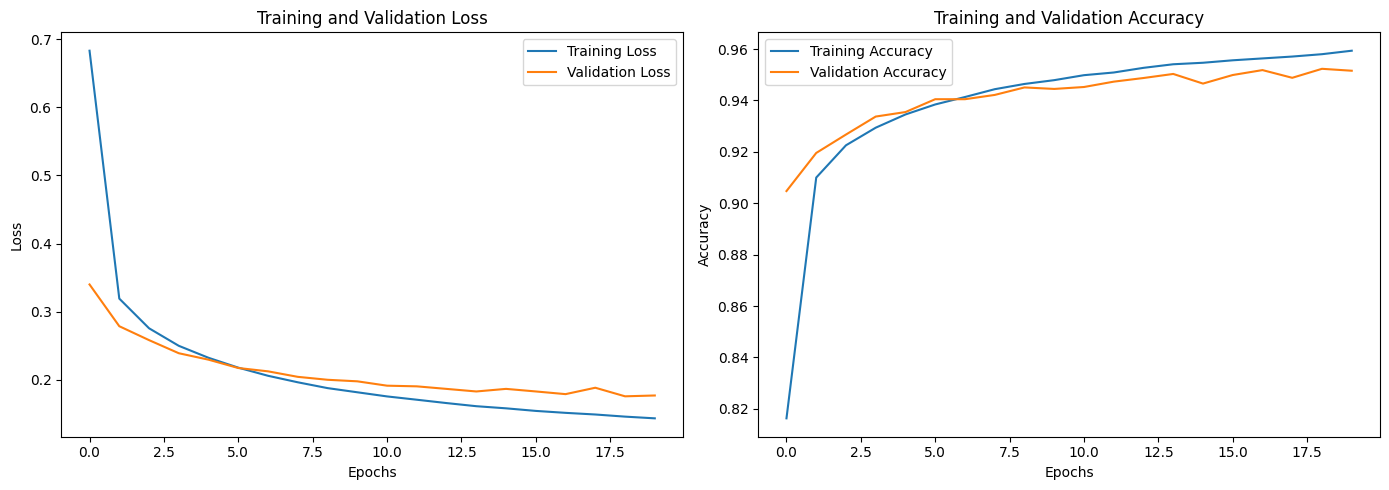

In [20]:
plot_convergence_history(history_underfit)